# Lab 3.1 — Understanding Data as Tensors


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
vector = np.array([10, 20, 30, 40])

print(vector)
print("Shape:", vector.shape)
print("Number of dimensions:", vector.ndim)

[10 20 30 40]
Shape: (4,)
Number of dimensions: 1


**Interpretation:** This is a 1D array with shape `(4,)`. It contains four values — no rows/columns structure, just a flat list.

### Task 2 — Create a matrix and print its shape

In [3]:
matrix = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

print(matrix)
print("Shape:", matrix.shape)
print("Number of dimensions:", matrix.ndim)

[[10 20 30]
 [40 50 60]
 [70 80 90]]
Shape: (3, 3)
Number of dimensions: 2


**Interpretation:** This is a 2D array with shape `(3, 3)` — 3 rows and 3 columns.

### Connecting the matrix to tabular data
In tabular ML: rows = examples, columns = features.

In [4]:
tabular_data = np.array([
    [2, 60, 50],
    [5, 80, 75],
    [8, 95, 90]
])

print(tabular_data)
print("Shape:", tabular_data.shape)

[[ 2 60 50]
 [ 5 80 75]
 [ 8 95 90]]
Shape: (3, 3)


| Study Hours | Attendance | Assignment Score |
|---|---|---|
| 2 | 60 | 50 |
| 5 | 80 | 75 |
| 8 | 95 | 90 |

## Part B: Single Grayscale Image as a 2D Tensor

### Task 3 — Create one grayscale image using NumPy

In [5]:
gray_image = np.array([
    [0,   0,   0,   0,   0,   0,   0,   0],
    [0, 255, 255, 255, 255, 255, 255,   0],
    [0, 255,   0,   0,   0,   0, 255,   0],
    [0, 255,   0, 255, 255,   0, 255,   0],
    [0, 255,   0, 255, 255,   0, 255,   0],
    [0, 255,   0,   0,   0,   0, 255,   0],
    [0, 255, 255, 255, 255, 255, 255,   0],
    [0,   0,   0,   0,   0,   0,   0,   0]
])

print(gray_image)
print("Shape:", gray_image.shape)
print("Number of dimensions:", gray_image.ndim)

[[  0   0   0   0   0   0   0   0]
 [  0 255 255 255 255 255 255   0]
 [  0 255   0   0   0   0 255   0]
 [  0 255   0 255 255   0 255   0]
 [  0 255   0 255 255   0 255   0]
 [  0 255   0   0   0   0 255   0]
 [  0 255 255 255 255 255 255   0]
 [  0   0   0   0   0   0   0   0]]
Shape: (8, 8)
Number of dimensions: 2


### Task 4 — Display the grayscale image

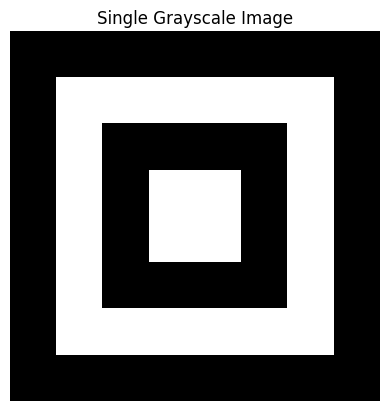

In [6]:
plt.imshow(gray_image, cmap="gray")
plt.title("Single Grayscale Image")
plt.axis("off")
plt.show()

**Interpretation:** The image is stored as `height x width` → `(8, 8)`. Each cell holds one intensity value (0 = black, 255 = white).

## Part C: Flattening an Image

### Task 5 — Flatten the grayscale image

In [7]:
flat_image = gray_image.flatten()

print(flat_image)
print("Original shape:", gray_image.shape)
print("Flattened shape:", flat_image.shape)

[  0   0   0   0   0   0   0   0   0 255 255 255 255 255 255   0   0 255
   0   0   0   0 255   0   0 255   0 255 255   0 255   0   0 255   0 255
 255   0 255   0   0 255   0   0   0   0 255   0   0 255 255 255 255 255
 255   0   0   0   0   0   0   0   0   0]
Original shape: (8, 8)
Flattened shape: (64,)


**Interpretation:** `(8, 8)` becomes `(64,)` because 8 x 8 = 64. The 2D image is converted into tabular-style 1D input, which classical ML models expect — but the neighboring-pixel relationships are lost in the process.

## Part D: Multiple Grayscale Images as a 3D Tensor

### Task 6 — Create a batch of grayscale images

In [8]:
image_1 = gray_image
image_2 = np.flipud(gray_image)
image_3 = np.fliplr(gray_image)

gray_batch = np.array([image_1, image_2, image_3])

print("Batch shape:", gray_batch.shape)
print("Number of dimensions:", gray_batch.ndim)

Batch shape: (3, 8, 8)
Number of dimensions: 3


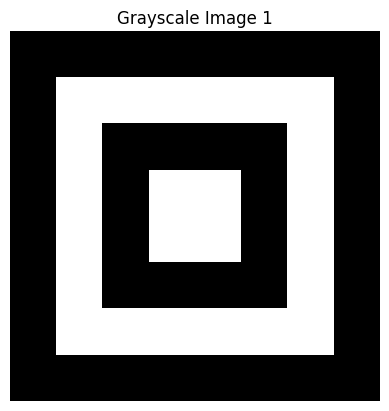

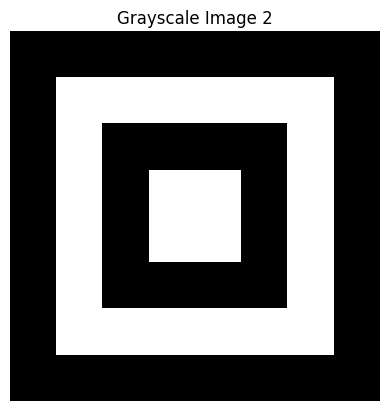

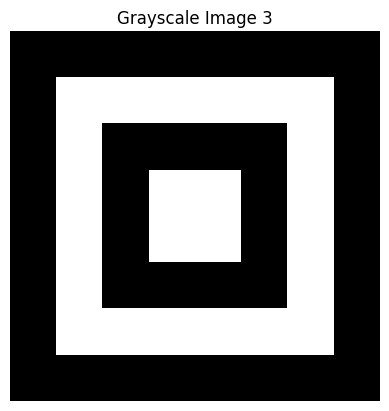

In [9]:
for i in range(gray_batch.shape[0]):
    plt.imshow(gray_batch[i], cmap="gray")
    plt.title(f"Grayscale Image {i + 1}")
    plt.axis("off")
    plt.show()

**Interpretation:** Shape `(3, 8, 8)` = 3 grayscale images, each 8 rows x 8 columns. Stacking images adds one extra dimension in front.

## Part E: Single Color Image as a 3D Tensor

### Task 7 — Create one RGB image

In [10]:
height = 8
width = 8
channels = 3

rgb_image = np.zeros((height, width, channels), dtype=np.uint8)

# Red square in top-left
rgb_image[0:4, 0:4, 0] = 255
# Green square in top-right
rgb_image[0:4, 4:8, 1] = 255
# Blue square in bottom-left
rgb_image[4:8, 0:4, 2] = 255
# White square in bottom-right
rgb_image[4:8, 4:8, :] = 255

print("RGB image shape:", rgb_image.shape)
print("Number of dimensions:", rgb_image.ndim)

RGB image shape: (8, 8, 3)
Number of dimensions: 3


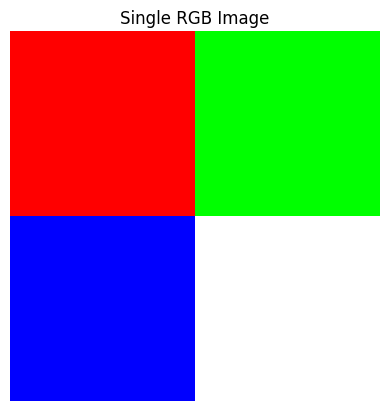

In [11]:
plt.imshow(rgb_image)
plt.title("Single RGB Image")
plt.axis("off")
plt.show()

**Interpretation:** Shape `(8, 8, 3)` = 8 rows, 8 columns, 3 color channels (Red, Green, Blue).

### Task 8 — Display individual RGB channels

In [12]:
red_channel = rgb_image[:, :, 0]
green_channel = rgb_image[:, :, 1]
blue_channel = rgb_image[:, :, 2]

print("Red channel shape:", red_channel.shape)
print("Green channel shape:", green_channel.shape)
print("Blue channel shape:", blue_channel.shape)

Red channel shape: (8, 8)
Green channel shape: (8, 8)
Blue channel shape: (8, 8)


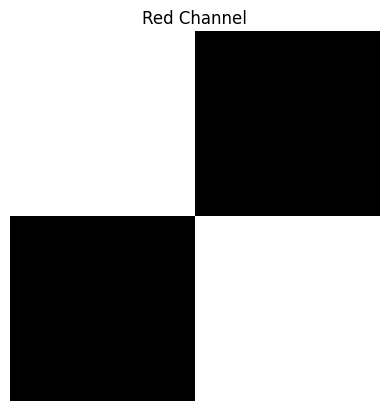

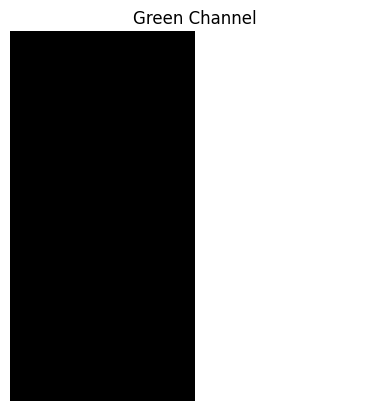

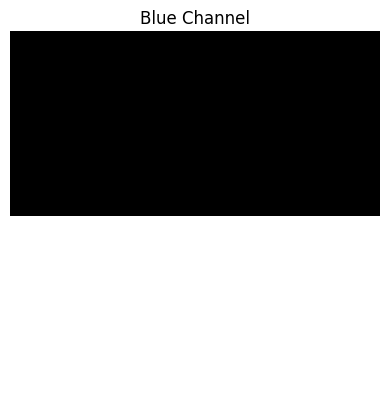

In [13]:
plt.imshow(red_channel, cmap="gray")
plt.title("Red Channel")
plt.axis("off")
plt.show()

plt.imshow(green_channel, cmap="gray")
plt.title("Green Channel")
plt.axis("off")
plt.show()

plt.imshow(blue_channel, cmap="gray")
plt.title("Blue Channel")
plt.axis("off")
plt.show()

## Part F: Flattening a Color Image

### Task 9 — Flatten the RGB image

In [14]:
flat_rgb_image = rgb_image.flatten()

print("Original RGB shape:", rgb_image.shape)
print("Flattened RGB shape:", flat_rgb_image.shape)

Original RGB shape: (8, 8, 3)
Flattened RGB shape: (192,)


**Interpretation:** `(8, 8, 3)` becomes `(192,)` because 8 x 8 x 3 = 192.

## Part G: Video as a 4D Tensor

### Task 10 — Create a video tensor with 5 frames

In [15]:
frames = []
for i in range(5):
    frame = np.zeros((8, 8, 3), dtype=np.uint8)
    # Moving red square
    frame[2:5, i:i+3, 0] = 255
    frames.append(frame)

video_tensor = np.array(frames)

print("Video tensor shape:", video_tensor.shape)
print("Number of dimensions:", video_tensor.ndim)

Video tensor shape: (5, 8, 8, 3)
Number of dimensions: 4


### Task 11 — Display each frame of the video

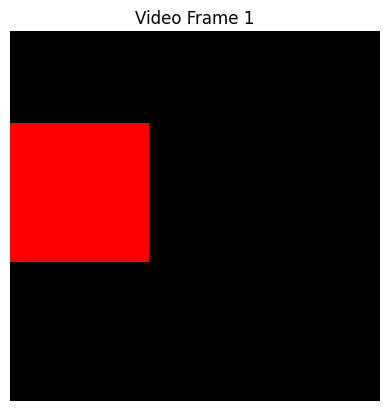

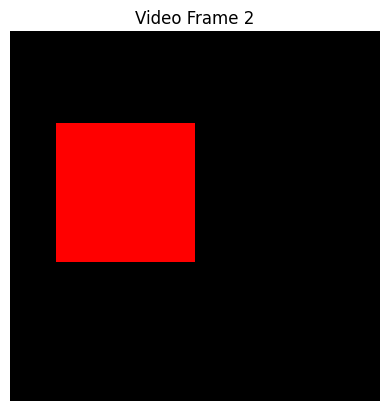

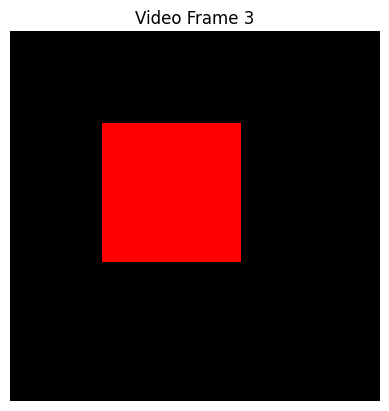

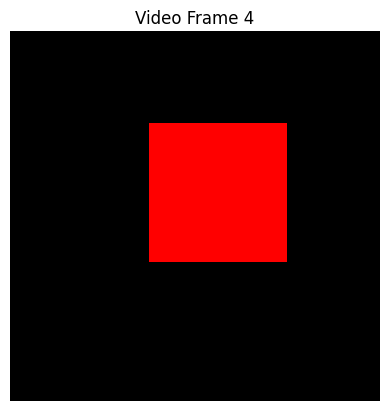

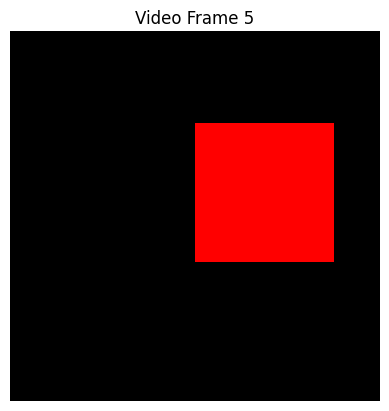

In [16]:
for i in range(video_tensor.shape[0]):
    plt.imshow(video_tensor[i])
    plt.title(f"Video Frame {i + 1}")
    plt.axis("off")
    plt.show()

**Interpretation:** Shape `(5, 8, 8, 3)` = 5 frames, each 8 x 8 with 3 color channels. A video is simply a sequence of RGB images stacked along a new "frame" dimension.

## Part H: Batch of Videos

### Task 12 — Create a batch of two videos

In [17]:
video_1 = video_tensor
video_2 = np.flip(video_tensor, axis=2)

video_batch = np.array([video_1, video_2])

print("Video batch shape:", video_batch.shape)
print("Number of dimensions:", video_batch.ndim)

Video batch shape: (2, 5, 8, 8, 3)
Number of dimensions: 5


**Interpretation:** Shape `(2, 5, 8, 8, 3)` = 2 videos, 5 frames per video, 8 rows, 8 columns, 3 color channels.

## Part I: Summary Table

### Task 13 — Explanation of each tensor shape

| Data Type | Tensor Shape | Meaning |
|---|---|---|
| One tabular record | `(features,)` | One row of features |
| Tabular dataset | `(samples, features)` | Many rows and columns |
| One grayscale image | `(height, width)` | 2D pixel grid |
| Multiple grayscale images | `(images, height, width)` | Batch of grayscale images |
| One RGB image | `(height, width, channels)` | Color image |
| Multiple RGB images | `(images, height, width, channels)` | Batch of color images |
| One video | `(frames, height, width, channels)` | Sequence of RGB frames |
| Multiple videos | `(videos, frames, height, width, channels)` | Batch of videos |

**General pattern:** each time we batch a data type, we add one more dimension in front. Grayscale → RGB adds a channel dimension. RGB → video adds a frame dimension.

## Part J: Connection to Machine Learning

**Classical ML** algorithms typically expect flat feature vectors:
`Image → Flatten → Vector → Classifier`

**Deep Learning** models can use the original structure directly:
`Image tensor → CNN`
`Video tensor → CNN + RNN / 3D CNN / Transformer`

**Key difference:** Flattening discards spatial relationships between neighboring pixels. CNNs instead preserve spatial structure and learn local patterns such as edges, corners, shapes, textures, and eventually whole objects.

## Part L: Reflection Questions

**1. Why is a grayscale image represented as a 2D tensor?**
A grayscale image has only one intensity value per pixel, and pixels are arranged in rows and columns. Two dimensions (height and width) are enough to locate every pixel, so no third dimension is needed.

**2. Why is an RGB image represented as a 3D tensor?**
Each pixel now needs three values instead of one — its red, green, and blue intensities. The extra "channel" dimension stores these three values per pixel, so we need `(height, width, channels)`.

**3. Why is a video represented as a 4D tensor?**
A video is a sequence of RGB images played over time. Each frame is already a 3D tensor `(height, width, channels)`, and stacking many frames in time order adds a fourth "frames" dimension: `(frames, height, width, channels)`.

**4. What happens when we flatten an image?**
The multi-dimensional pixel grid is reshaped into a single long 1D vector. All the values are preserved, but their 2D (or 3D) arrangement — which pixel was next to which — is lost; the data becomes a plain list of numbers.

**5. Why can flattening be useful for classical ML?**
Many classical algorithms (e.g., logistic regression, SVMs, decision trees) are designed to take a fixed-length feature vector as input, the same way tabular data is structured as `(samples, features)`. Flattening converts an image into that expected format so these models can process it.

**6. Why can flattening be harmful for image understanding?**
Images have meaningful spatial structure — nearby pixels often belong to the same edge, shape, or object. Flattening scrambles this local neighborhood information into an arbitrary 1D order, making it much harder for a model to learn patterns like edges or shapes.

**7. Why are CNNs better suited for image data than simple flattened input?**
CNNs use convolutional filters that slide across the 2D (or 3D) image and look at small local neighborhoods of pixels at a time. This lets them directly detect spatial patterns such as edges, corners, and textures, and build up to more complex shapes and objects — something a flattened vector and a fully-connected layer cannot do as efficiently.

**8. What does the channel dimension mean in an RGB image?**
The channel dimension stores the separate color intensity values for each pixel — typically Red, Green, and Blue. A pixel's true color is a combination of its three channel values.

**9. What does the frame dimension mean in a video?**
The frame dimension represents time — each "frame" is one still image captured at a specific moment, and the sequence of frames in order shows how the scene changes over time.

**10. How is tabular data different from image data?**
Tabular data is organized as independent rows (examples) and columns (features), where columns don't necessarily have any spatial or sequential relationship to each other. Image data has an inherent spatial structure — pixel values are meaningfully related to their neighbors — and video data adds a temporal (time-based) relationship between frames as well.

## Final Takeaway

| Data | Tensor |
|---|---|
| Table | Matrix |
| Grayscale image | 2D tensor |
| Color image | 3D tensor |
| Video | 4D tensor |
| Batch of data | Adds one more dimension |

Machine Learning begins by representing real-world data as numbers — and tensors are the structure that makes this possible across tables, images, and videos alike.